Question: Testing effect of training depth when using Nadam with scheduled learning rate


In [6]:
import os, shutil
import keras
from training import TrainingHistory, fit_model
from training import fit_model
# from training_data import TrainingData, Normalizer
import matplotlib.pyplot as plt

In [2]:
save_path = "models/test_depth_with_schedule"
training_data_path = "training_data"

In [3]:
from training_data import load_training_data
training_data = load_training_data(training_data_path)
levels = list(training_data.levels.keys())
depths = [1.0, 0.9, 0.8, 0.6, 0.2]
save_paths = {depth:f"{save_path}/depth_{depth:0.02f}" for depth in depths}

In [7]:
if os.path.exists(save_path):
    shutil.rmtree(save_path)
training_level = 'd0.40'
for depth in depths:
    print(f"=== training at depth {depth} ===")
    fit_model(
        training_data=training_data_path,
        training_level=training_level,
        train_depth=depth,
        optimizer=keras.optimizers.Nadam(),
        rate_scheduler={'delay': 2, 'decay': 0.8},
        save_path=save_paths[depth],
        model_type='ResNet101V2',
    )

=== training at depth 1.0 ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False


2023-10-27 13:08:49.605625: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1639] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22247 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3090, pci bus id: 0000:65:00.0, compute capability: 8.6


Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None
Epoch 1/10


2023-10-27 13:09:22.255455: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:432] Loaded cuDNN version 8600
2023-10-27 13:09:23.593952: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:606] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2023-10-27 13:09:24.600794: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x1ede45e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2023-10-27 13:09:24.600842: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 3090, Compute Capability 8.6
2023-10-27 13:09:24.627337: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:255] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2023-10-27 13:09:24.852313: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the proce


Batch 0


...

 100/1554 [>.............................] - ETA: 9:54 - loss: 0.0924
Batch 100
    Training MSE (xyz, xy, z): 0.10098907485744822 0.10709433131010743 0.0887785619521298  Slopes: [-0.014597483131876967, -0.013710227828330654, -0.01596926794760722]
    Validation d0.00  MSE (xyz, xy, z): 0.0491 0.0572 0.0328  Slopes: -0.0162 -0.00592 -0.0189
    Validation d0.20  MSE (xyz, xy, z): 0.055 0.0648 0.0354  Slopes: -0.0165 -0.0125 -0.0188
    Validation d0.40  MSE (xyz, xy, z): 0.112 0.131 0.0758  Slopes: -0.0139 -0.0117 -0.0168
    Validation d0.60  MSE (xyz, xy, z): 0.267 0.278 0.243  Slopes: -0.0101 -0.0104 -0.00933
    Validation d0.80  MSE (xyz, xy, z): 0.579 0.669 0.4  Slopes: -0.00697 -0.00687 -0.00731
    Validation d1.00  MSE (xyz, xy, z): 0.865 1.07 0.453  Slopes: -0.00679 -0.00678 -0.00683
 200/1554 [==>...........................] - ETA: 13:35 - loss: 0.0704
Batch 200
    Training MSE (xyz, xy, z): 0.05775840778658616 0.06706659095542283 0.03914204144891281  Slopes: [-0.0109681184

INFO:tensorflow:Assets written to: models/test_depth_with_schedule/depth_0.60/fit_model/assets


=== training at depth 0.2 ===
GPUS: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')] False
Loaded 99500 training examples and 3000 validation examples
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None
Epoch 1/10

Batch 0
saving weigts 

 100/1554 [>.............................] - ETA: 11:00 - loss: 0.0987
Batch 100
    Training MSE (xyz, xy, z): 0.23039902407733517 0.2851355003797721 0.12092607147246132  Slopes: [-0.012289616939017107, -0.010969220088072192, -0.015436319944208788]
    Validation d0.00  MSE (xyz, xy, z): 0.252 0.356 0.0453  Slopes: -0.00982 -0.00964 -0.012
    Validation d0.20  MSE (xyz, xy, z): 0.24 0.317 0.0849  Slopes: -0.0105 -0.00957 -0.0144
    Validation d0.40  MSE (xyz, xy, z): 0.261 0.32 0.142  Slopes: -0.0111 -0.00948 -0.0148
    Validation d0.60  MSE (xyz, xy, z): 0.536 0.593 0.423  Slopes: -0.00852 -0.00673 -0.0117
    Validation d0.80  MSE (xyz, xy, z): 1.03 1.2 0.686  Slopes: -0.00535 -0.00333 -0.00973
    Validation d1.00  MSE (xyz, xy, z): 1.17 1.43 0.638  Slopes: -0.0049 -0.00172 -0.0115
 200/1554 [==>...........................] - ETA: 14:40 - loss: 0.0762
Batch 200
    Training MSE (xyz, xy, z): 0.14257679533248366 0.17074100499899694 0.08624837599945712  Slopes: [-0.009219584269309

INFO:tensorflow:Assets written to: models/test_depth_with_schedule/depth_0.20/fit_model/assets


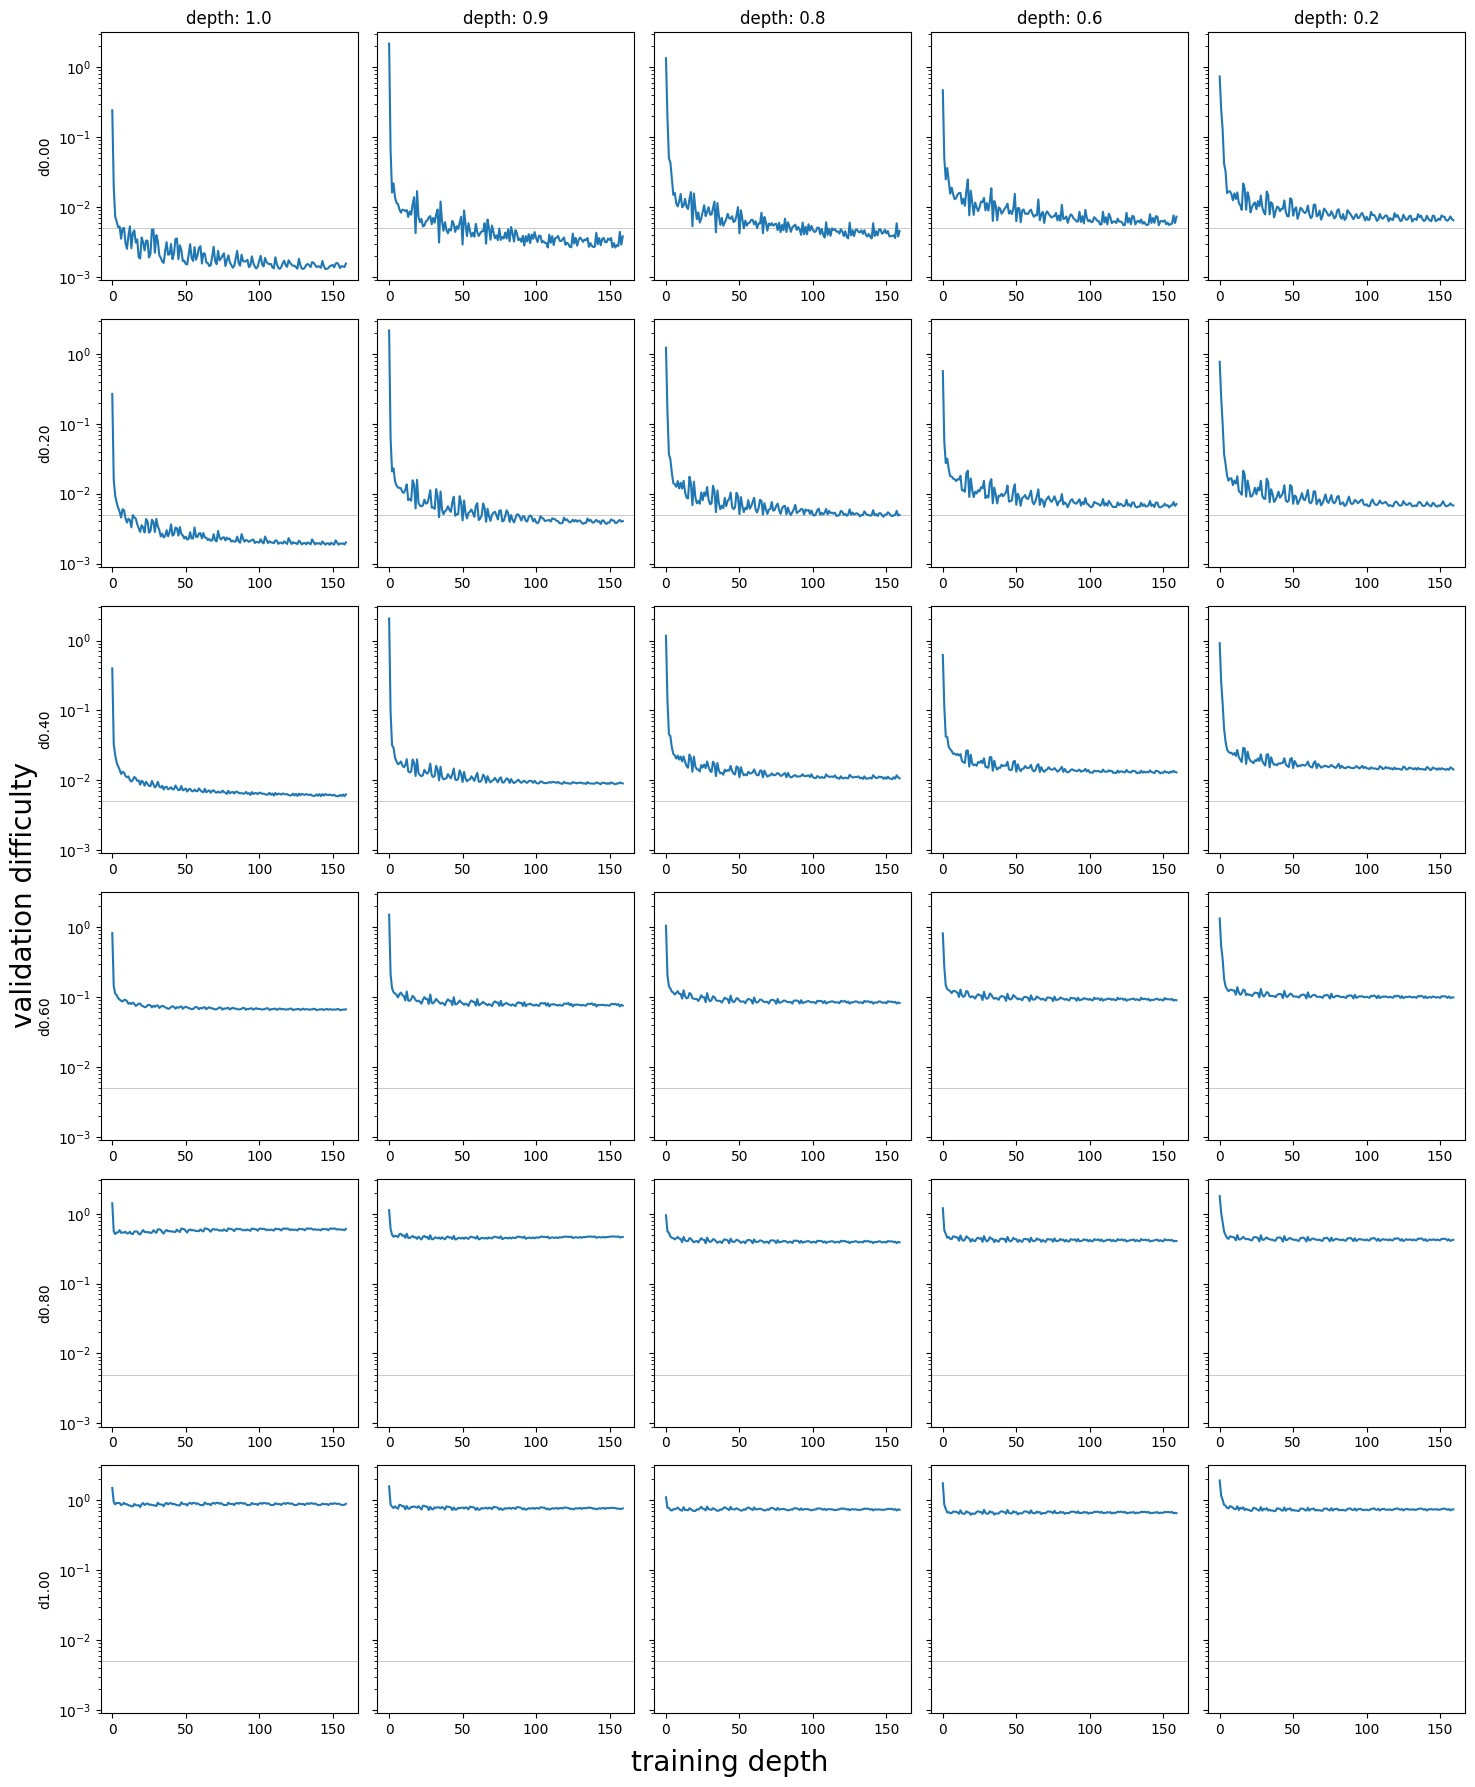

In [8]:
fig, ax = plt.subplots(len(levels), len(depths), figsize=(len(depths)*3, len(levels)*3), sharey=True)
fig.supylabel('validation difficulty', fontsize=20)
fig.supxlabel('training depth', fontsize=20)
for i, level in enumerate(levels):
    ax[i, 0].set_ylabel(level)
for i,depth in enumerate(depths):
    history = TrainingHistory(f'{save_paths[depth]}/training_history.json')
    history.plot_loss(metrics=['mse'], ax=ax[:, i:i+1])
    ax[0, i].set_title(f"depth: {depth}")
fig.tight_layout()

In [11]:
from model import PipetteDetectionModel
depth = 0.8
model = PipetteDetectionModel(load_model=save_paths[depth])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101v2 (Functional)    (None, 16, 16, 2048)      42626560  
                                                                 
 global_average_pooling2d (  (None, 2048)              0         
 GlobalAveragePooling2D)                                         
                                                                 
 dense (Dense)               (None, 3)                 6147      
                                                                 
Total params: 42632707 (162.63 MB)
Trainable params: 6147 (24.01 KB)
Non-trainable params: 42626560 (162.61 MB)
_________________________________________________________________
None


1/1 [==============================] - 0s 64ms/step


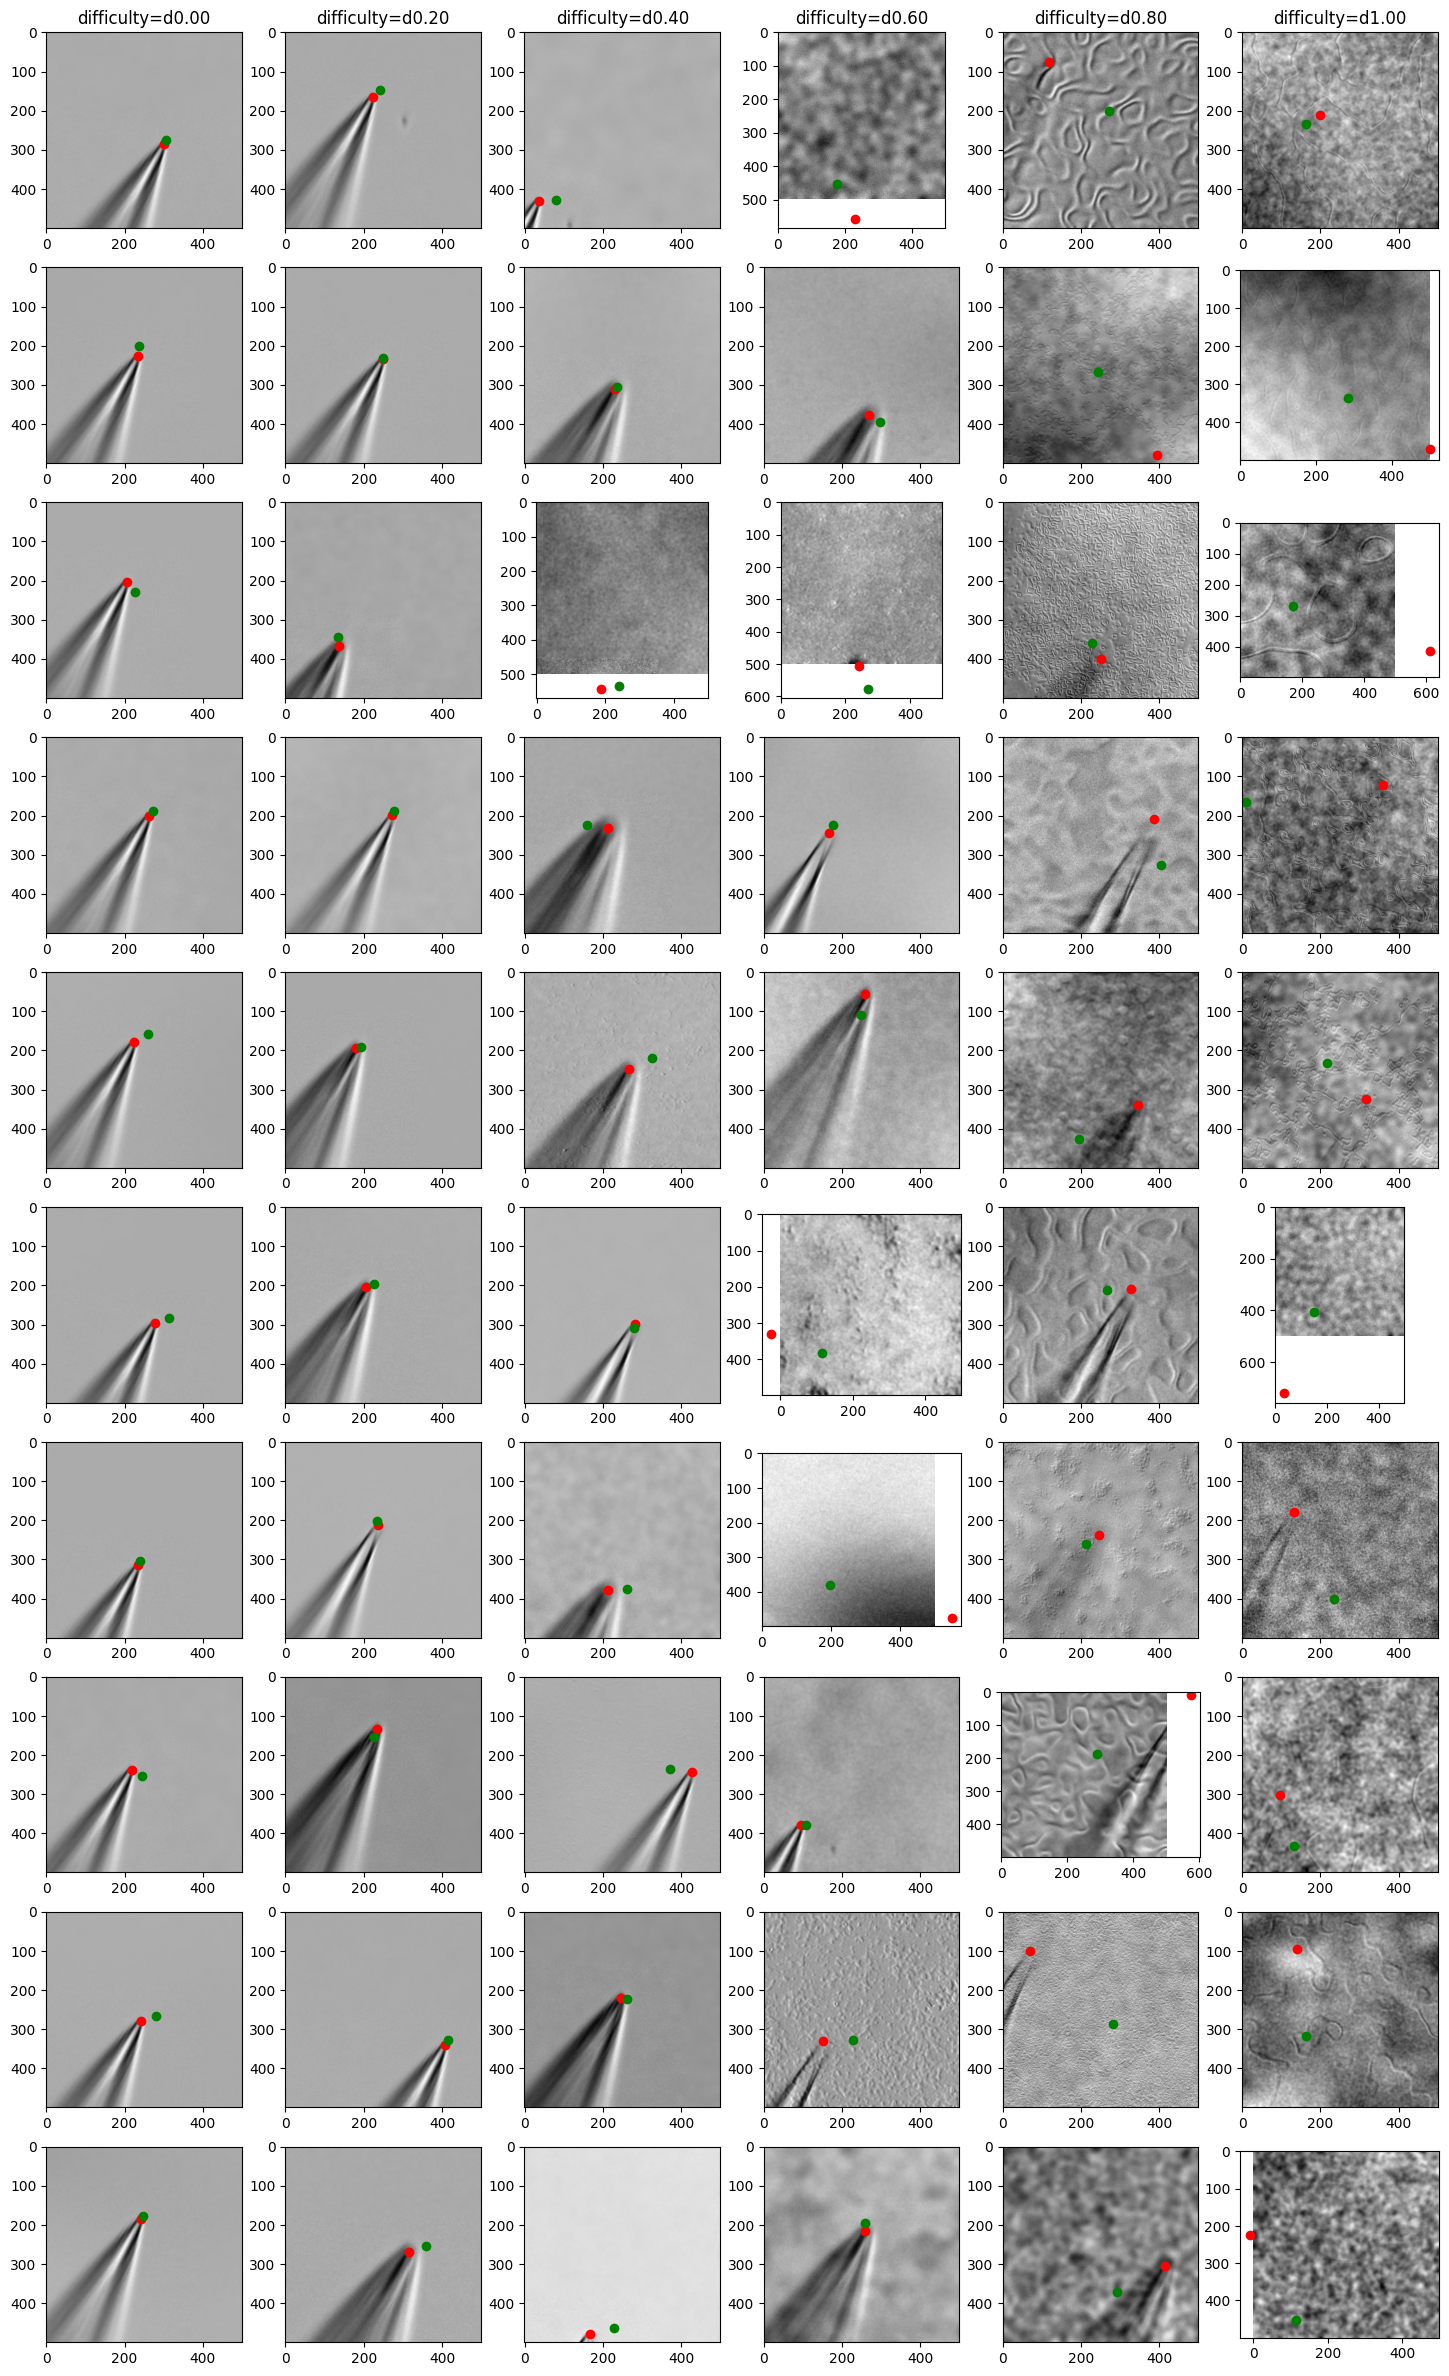

In [12]:
shape = (10, len(levels))
fig, ax = plt.subplots(shape[0], shape[1], figsize=(shape[1]*3, shape[0]*3))

for j, level in enumerate(levels):
    ax[0,j].set_title(f"difficulty={level}")
    image, pip_pos = training_data.levels[level][:shape[0]].get_arrays()
    pip_pos = training_data.output_norm.denormalize(pip_pos)
    pred = training_data.output_norm.denormalize(model.model.predict(image))
    for i in range(shape[0]):
        ax[i,j].imshow(image[i], cmap='gray')
        ax[i,j].scatter(pip_pos[i, 2], pip_pos[i, 1], color='red')
        ax[i,j].scatter(pred[i, 2], pred[i, 1], color='green')
        